# Week 9 - Streamlit App Model

This optional Week 9 notebook trains models for the Streamlit prediction app.

The required simple app only asks for four property inputs:

- `LivingArea`
- `BedroomsTotal`
- `BathroomsTotalInteger`
- `LotSizeSquareFeet`

Because a four-input model does not know location, it is only a rough size-based demo. To make the app more useful, I also train an advanced app model that adds one extra user input: `CountyOrParish`. This is still simple enough for an app, but it uses location information, which is critical in real estate pricing.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor

    XGBOOST_AVAILABLE = True
except ModuleNotFoundError:
    XGBOOST_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("ggplot")

RANDOM_STATE = 42
PROJECT_ROOT = Path("..").resolve()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TRAIN_PATH = OUTPUT_DIR / "train_preprocessed.csv"
TEST_PATH = OUTPUT_DIR / "test_preprocessed.csv"

print(f"Train path: {TRAIN_PATH}")
print(f"Test path: {TEST_PATH}")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")

Train path: /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/train_preprocessed.csv
Test path: /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/test_preprocessed.csv
XGBoost available: True


## Load Train/Test Data

This notebook keeps the same team-standard split created in Week 3:

- Training data: `2025-06` through `2026-04`
- Test data: `2026-05`

I train two app-ready models:

1. A required simple model using only the four Week 9 input fields.
2. An advanced app model using the same four fields plus `CountyOrParish`.

In [2]:
train_df = pd.read_csv(TRAIN_PATH, parse_dates=["CloseDate", "close_month"])
test_df = pd.read_csv(TEST_PATH, parse_dates=["CloseDate", "close_month"])

simple_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
]
advanced_features = simple_features + ["CountyOrParish"]
app_features = simple_features
county_options = sorted(train_df["CountyOrParish"].dropna().unique())
target_col = "ClosePrice"

required_cols = advanced_features + [target_col]
missing_train = [col for col in required_cols if col not in train_df.columns]
missing_test = [col for col in required_cols if col not in test_df.columns]
if missing_train or missing_test:
    raise ValueError(f"Missing columns. train={missing_train}, test={missing_test}")

train_months = sorted(train_df["close_month"].dt.strftime("%Y-%m").unique())
test_months = sorted(test_df["close_month"].dt.strftime("%Y-%m").unique())

print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Train months: {train_months[0]} to {train_months[-1]}")
print(f"Test months: {test_months}")
print(f"County options: {len(county_options)}")

display(train_df[advanced_features + [target_col]].describe(include="all"))

Train rows: 117,996
Test rows: 12,007
Train months: 2025-06 to 2026-04
Test months: ['2026-05']
County options: 60


,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,CountyOrParish,ClosePrice
count,117996.0000,117996.0000,117984.0000,115896.0000,117996,117996.0000
unique,NaN,NaN,NaN,NaN,60,NaN
top,NaN,NaN,NaN,NaN,Los Angeles,NaN
freq,NaN,NaN,NaN,NaN,29412,NaN
mean,2048.2934,3.4933,2.6304,419718.6856,NaN,1346305.4286
std,1047.6816,0.9627,1.1280,18881061.0316,NaN,8658160.0027
min,312.0000,0.0000,0.0000,0.0300,NaN,8000.0000
25%,1386.0000,3.0000,2.0000,5663.0000,NaN,622997.5000
50%,1818.0000,3.0000,2.0000,7287.0000,NaN,885000.0000
75%,2439.0000,4.0000,3.0000,10454.0000,NaN,1400000.0000


## Basic Data Checks

Before training, I check the four app inputs and the target distribution. This helps explain why a four-input model is limited: the same size home can sell for very different prices depending on location and market context.

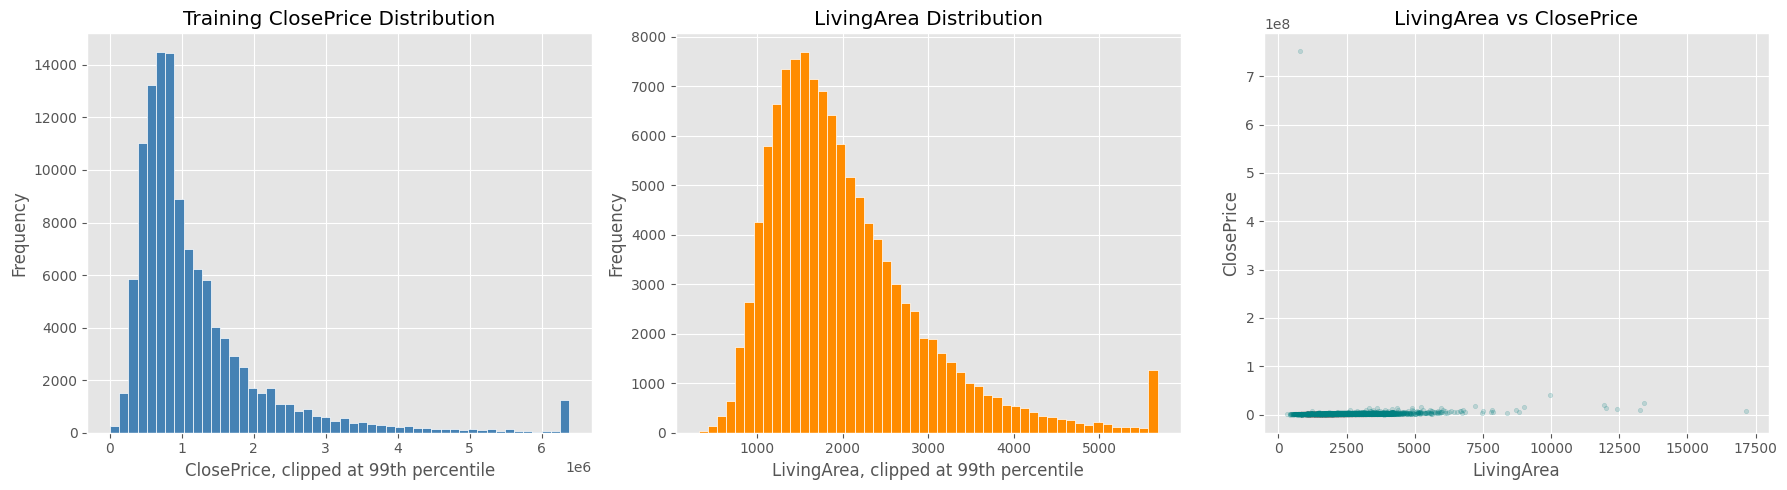

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_df[target_col].clip(upper=train_df[target_col].quantile(0.99)).plot(
    kind="hist", bins=50, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Training ClosePrice Distribution")
axes[0].set_xlabel("ClosePrice, clipped at 99th percentile")

train_df["LivingArea"].clip(upper=train_df["LivingArea"].quantile(0.99)).plot(
    kind="hist", bins=50, ax=axes[1], color="darkorange", edgecolor="white"
)
axes[1].set_title("LivingArea Distribution")
axes[1].set_xlabel("LivingArea, clipped at 99th percentile")

sample_df = train_df.sample(min(5000, len(train_df)), random_state=RANDOM_STATE)
axes[2].scatter(
    sample_df["LivingArea"],
    sample_df[target_col],
    alpha=0.18,
    s=10,
    color="teal",
)
axes[2].set_title("LivingArea vs ClosePrice")
axes[2].set_xlabel("LivingArea")
axes[2].set_ylabel("ClosePrice")

plt.tight_layout()
plt.show()

## Train Simple App Models

I compare several small models instead of assuming one model is best. The target is transformed with `log1p` for the non-dummy models so extreme luxury prices have less influence during training.

In [4]:
def evaluate_predictions(y_true, preds):
    y_true = pd.Series(y_true).reset_index(drop=True)
    preds = pd.Series(preds).reset_index(drop=True)
    ape = (y_true - preds).abs() / y_true
    return {
        "MAE": mean_absolute_error(y_true, preds),
        "RMSE": np.sqrt(mean_squared_error(y_true, preds)),
        "R2": r2_score(y_true, preds),
        "MAPE": ape.mean(),
        "MdAPE": ape.median(),
        "min_prediction": preds.min(),
        "max_prediction": preds.max(),
        "predictions_under_0": int((preds < 0).sum()),
        "predictions_over_50m": int((preds > 50_000_000).sum()),
    }


def make_numeric_pipeline(model, use_log_target=True, scale=False):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", model))
    pipeline = Pipeline(steps=steps)
    if use_log_target:
        pipeline = TransformedTargetRegressor(
            regressor=pipeline,
            func=np.log1p,
            inverse_func=np.expm1,
        )
    return pipeline


X_train = train_df[app_features].copy()
y_train = train_df[target_col].copy()
X_test = test_df[app_features].copy()
y_test = test_df[target_col].copy()

candidate_models = {
    "median_dummy": make_numeric_pipeline(
        DummyRegressor(strategy="median"), use_log_target=False, scale=False
    ),
    "linear_log_4_inputs": make_numeric_pipeline(
        LinearRegression(), use_log_target=True, scale=True
    ),
    "ridge_log_4_inputs": make_numeric_pipeline(
        Ridge(alpha=10.0), use_log_target=True, scale=True
    ),
    "hist_gradient_boosting_log_4_inputs": make_numeric_pipeline(
        HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.04,
            max_leaf_nodes=15,
            min_samples_leaf=50,
            l2_regularization=0.1,
            random_state=RANDOM_STATE,
        ),
        use_log_target=True,
        scale=False,
    ),
    "random_forest_log_4_inputs": make_numeric_pipeline(
        RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=50,
            max_features=1.0,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        use_log_target=True,
        scale=False,
    ),
}

results = []
fitted_models = {}
prediction_store = {}

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds = np.maximum(preds, 0)
    metrics = evaluate_predictions(y_test, preds)
    results.append({"model_name": model_name, **metrics})
    fitted_models[model_name] = model
    prediction_store[model_name] = preds

results_df = (
    pd.DataFrame(results)
    .sort_values(
        ["predictions_under_0", "predictions_over_50m", "MdAPE", "MAPE"],
        ascending=[True, True, True, True],
    )
    .reset_index(drop=True)
)

display(results_df)

,model_name,MAE,RMSE,R2,MAPE,MdAPE,min_prediction,max_prediction,predictions_under_0,predictions_over_50m
0,hist_gradient_boosting_log_4_inputs,516220.6350,1398761.4163,0.3042,0.4400,0.3120,238429.4850,13821700.3477,0,0
1,random_forest_log_4_inputs,534154.8093,1404465.4041,0.2985,0.4602,0.3365,263866.1336,14416546.4191,0,0
2,median_dummy,686182.1730,1729566.2304,-0.0638,0.5378,0.4048,885000.0000,885000.0000,0,0
3,linear_log_4_inputs,853370.6852,29814125.9038,-315.1114,0.4986,0.3575,459765.6333,3272303321.9970,0,2
4,ridge_log_4_inputs,853181.4357,29795243.6802,-314.7111,0.4986,0.3575,459744.6341,3270234565.4387,0,2


## Select App Model

For this app, I prioritize `MdAPE` and prediction sanity over `R²`. Since the app only uses four inputs, the model will miss location effects. The best model should therefore be interpreted as the least-bad simplified app model, not the best overall project model.

In [5]:
selected_model_name = results_df.iloc[0]["model_name"]
selected_model = fitted_models[selected_model_name]
selected_preds = prediction_store[selected_model_name]

print(f"Selected app model: {selected_model_name}")
display(results_df.head())

prediction_df = test_df[[target_col]].copy()
prediction_df["predicted"] = selected_preds
prediction_df["residual"] = prediction_df[target_col] - prediction_df["predicted"]
prediction_df["ape"] = prediction_df["residual"].abs() / prediction_df[target_col]

display(prediction_df[[target_col, "predicted", "residual", "ape"]].head())

Selected app model: hist_gradient_boosting_log_4_inputs


,model_name,MAE,RMSE,R2,MAPE,MdAPE,min_prediction,max_prediction,predictions_under_0,predictions_over_50m
0,hist_gradient_boosting_log_4_inputs,516220.6350,1398761.4163,0.3042,0.4400,0.3120,238429.4850,13821700.3477,0,0
1,random_forest_log_4_inputs,534154.8093,1404465.4041,0.2985,0.4602,0.3365,263866.1336,14416546.4191,0,0
2,median_dummy,686182.1730,1729566.2304,-0.0638,0.5378,0.4048,885000.0000,885000.0000,0,0
3,linear_log_4_inputs,853370.6852,29814125.9038,-315.1114,0.4986,0.3575,459765.6333,3272303321.9970,0,2
4,ridge_log_4_inputs,853181.4357,29795243.6802,-314.7111,0.4986,0.3575,459744.6341,3270234565.4387,0,2


,ClosePrice,predicted,residual,ape
0,8712500.0000,5510921.2656,3201578.7344,0.3675
1,1100000.0000,835233.9243,264766.0757,0.2407
2,1625000.0000,829671.1480,795328.8520,0.4894
3,1560000.0000,876872.8270,683127.1730,0.4379
4,605000.0000,1408778.6909,-803778.6909,1.3286


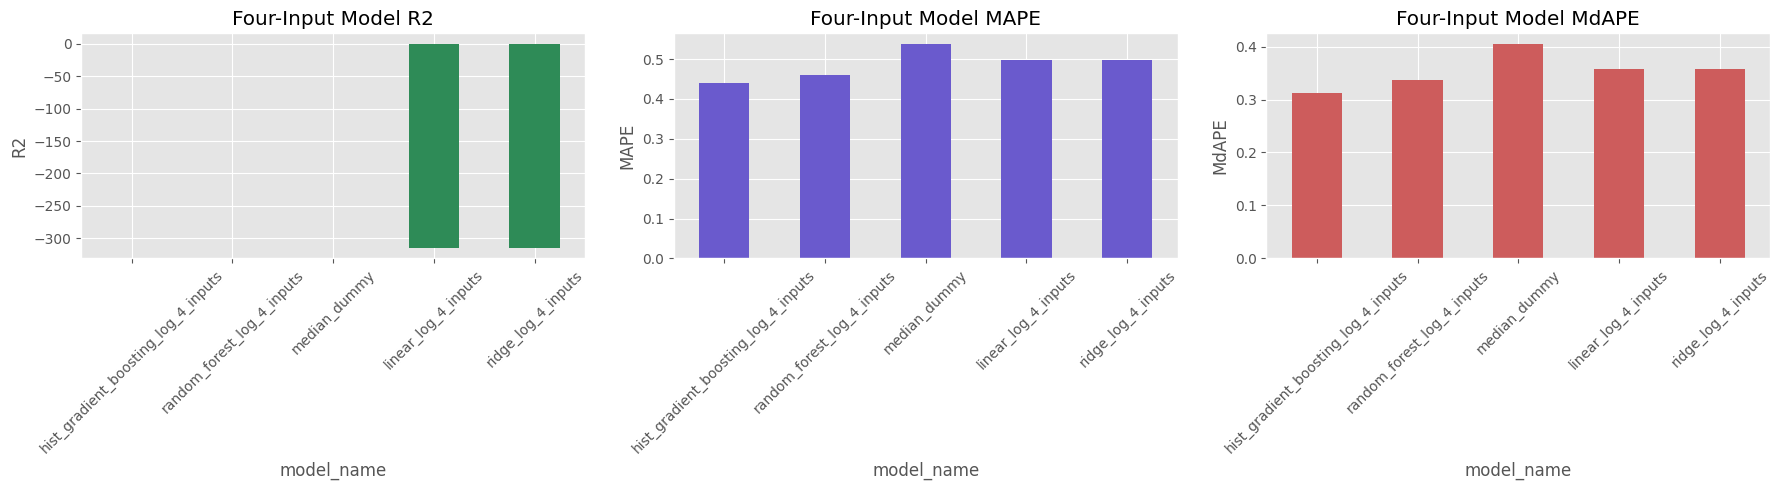

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_df.plot(
    x="model_name", y="R2", kind="bar", ax=axes[0], legend=False, color="seagreen"
)
axes[0].set_title("Four-Input Model R2")
axes[0].set_ylabel("R2")

results_df.plot(
    x="model_name", y="MAPE", kind="bar", ax=axes[1], legend=False, color="slateblue"
)
axes[1].set_title("Four-Input Model MAPE")
axes[1].set_ylabel("MAPE")

results_df.plot(
    x="model_name", y="MdAPE", kind="bar", ax=axes[2], legend=False, color="indianred"
)
axes[2].set_title("Four-Input Model MdAPE")
axes[2].set_ylabel("MdAPE")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

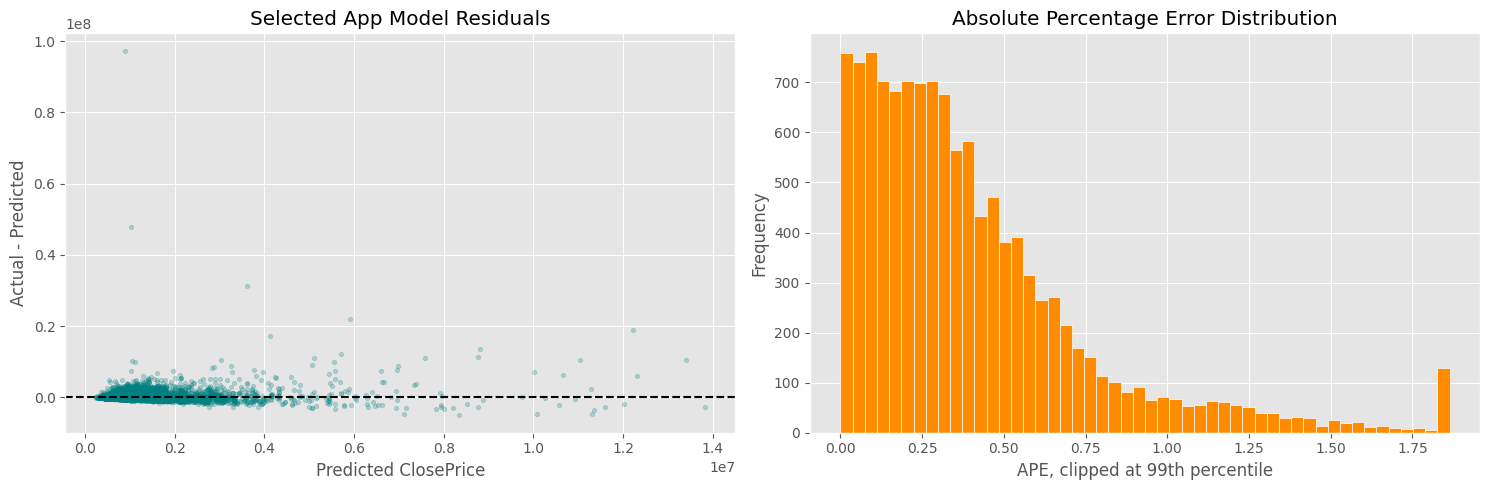

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(
    prediction_df["predicted"],
    prediction_df["residual"],
    alpha=0.25,
    s=10,
    color="teal",
)
axes[0].axhline(0, linestyle="--", color="black")
axes[0].set_title("Selected App Model Residuals")
axes[0].set_xlabel("Predicted ClosePrice")
axes[0].set_ylabel("Actual - Predicted")

prediction_df["ape"].clip(upper=prediction_df["ape"].quantile(0.99)).plot(
    kind="hist", bins=50, ax=axes[1], color="darkorange", edgecolor="white"
)
axes[1].set_title("Absolute Percentage Error Distribution")
axes[1].set_xlabel("APE, clipped at 99th percentile")

plt.tight_layout()
plt.show()

## Train County-Enhanced XGBoost App Model

The four-input model is weak because it has no location information. This section trains a second app model that adds `CountyOrParish` as one dropdown input.

This is not the full Week 7 XGBoost model, because the app still does not ask for list price, year built, latitude, longitude, school district, or market-context fields. However, it reuses the same core idea from Week 7: XGBoost with a log-transformed target to reduce the impact of extreme prices.

In [8]:
def make_mixed_preprocessor(feature_cols, fit_df):
    numeric_features = (
        fit_df[feature_cols].select_dtypes(include=["number"]).columns.tolist()
    )
    categorical_features = [col for col in feature_cols if col not in numeric_features]

    numeric_transformer = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="median"))]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=25)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )


def make_xgb_county_pipeline(feature_cols, fit_df):
    if not XGBOOST_AVAILABLE:
        raise ModuleNotFoundError(
            "XGBoost is not installed. Run `pip install xgboost`, then rerun this notebook."
        )

    xgb = XGBRegressor(
        objective="reg:squarederror",
        max_depth=3,
        learning_rate=0.03,
        n_estimators=600,
        min_child_weight=15,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    pipeline = Pipeline(
        steps=[
            ("preprocess", make_mixed_preprocessor(feature_cols, fit_df)),
            ("model", xgb),
        ]
    )
    return TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
    )


X_train_advanced = train_df[advanced_features].copy()
X_test_advanced = test_df[advanced_features].copy()

advanced_model = make_xgb_county_pipeline(advanced_features, train_df)
advanced_model.fit(X_train_advanced, y_train)
advanced_preds = np.maximum(advanced_model.predict(X_test_advanced), 0)
advanced_metrics = evaluate_predictions(y_test, advanced_preds)

advanced_results_df = pd.DataFrame(
    [
        {
            "model_name": "xgb_log_county_5_inputs",
            "feature_count": len(advanced_features),
            **advanced_metrics,
        }
    ]
)

display(advanced_results_df)

,model_name,feature_count,MAE,RMSE,R2,MAPE,MdAPE,min_prediction,max_prediction,predictions_under_0,predictions_over_50m
0,xgb_log_county_5_inputs,5,397437.7387,1335233.1767,0.3660,0.3054,0.2022,165319.7969,13130615.0000,0,0


,app_version,model_name,R2,MAPE,MdAPE,MAE,RMSE
0,Advanced county app,xgb_log_county_5_inputs,0.3660,0.3054,0.2022,397437.7387,1335233.1767
1,Simple four-input app,hist_gradient_boosting_log_4_inputs,0.3042,0.4400,0.3120,516220.6350,1398761.4163
2,Simple four-input app,random_forest_log_4_inputs,0.2985,0.4602,0.3365,534154.8093,1404465.4041
3,Simple four-input app,linear_log_4_inputs,-315.1114,0.4986,0.3575,853370.6852,29814125.9038
4,Simple four-input app,ridge_log_4_inputs,-314.7111,0.4986,0.3575,853181.4357,29795243.6802
5,Simple four-input app,median_dummy,-0.0638,0.5378,0.4048,686182.1730,1729566.2304


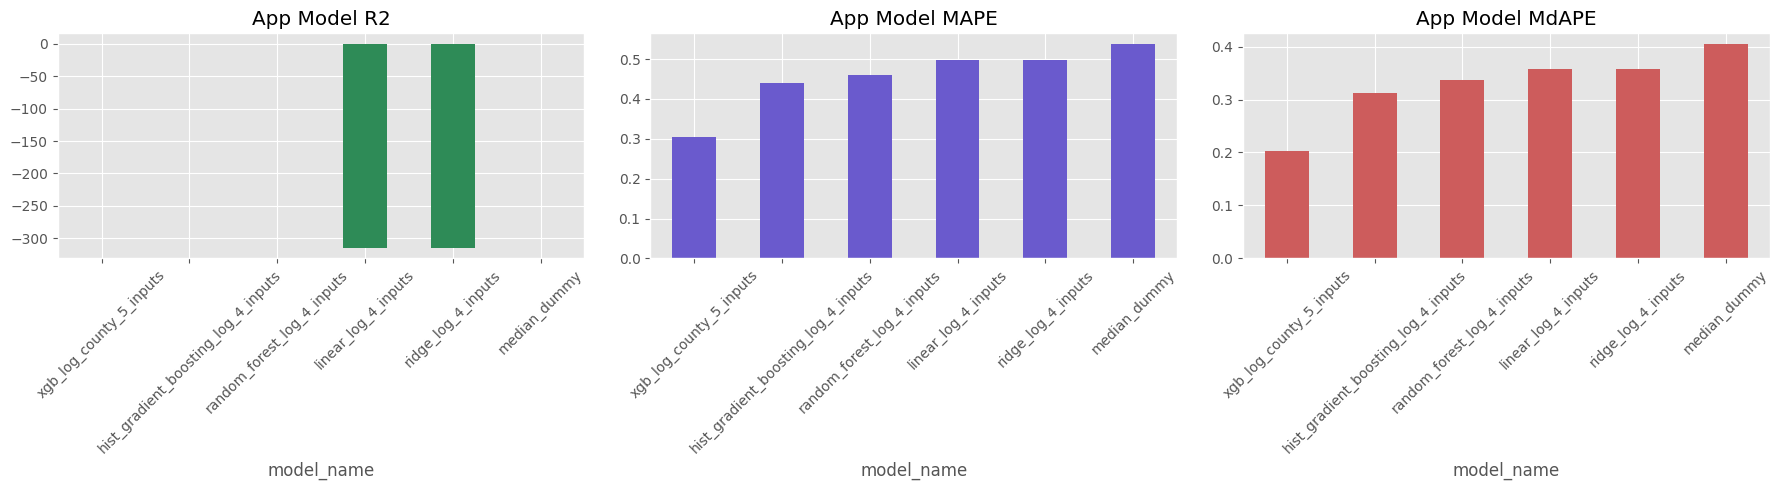

In [9]:
comparison_for_app_df = (
    pd.concat(
        [
            results_df.assign(app_version="Simple four-input app"),
            advanced_results_df.assign(app_version="Advanced county app"),
        ],
        ignore_index=True,
    )
    .sort_values(["MdAPE", "MAPE"])
    .reset_index(drop=True)
)

display(
    comparison_for_app_df[
        ["app_version", "model_name", "R2", "MAPE", "MdAPE", "MAE", "RMSE"]
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df = comparison_for_app_df.head(6)
plot_df.plot(
    x="model_name", y="R2", kind="bar", ax=axes[0], legend=False, color="seagreen"
)
axes[0].set_title("App Model R2")
plot_df.plot(
    x="model_name", y="MAPE", kind="bar", ax=axes[1], legend=False, color="slateblue"
)
axes[1].set_title("App Model MAPE")
plot_df.plot(
    x="model_name", y="MdAPE", kind="bar", ax=axes[2], legend=False, color="indianred"
)
axes[2].set_title("App Model MdAPE")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Save Model For Streamlit

The saved model is loaded by `app.py` using `joblib`. I also save the model metrics and a simple training-data profile so the app can show a rough prediction interval and compare user inputs with typical training values.

In [10]:
model_path = OUTPUT_DIR / "streamlit_price_model.joblib"
advanced_model_path = OUTPUT_DIR / "streamlit_xgb_county_model.joblib"
results_path = OUTPUT_DIR / "streamlit_app_model_results.csv"
advanced_results_path = OUTPUT_DIR / "streamlit_app_advanced_model_results.csv"
combined_results_path = OUTPUT_DIR / "streamlit_app_all_model_results.csv"
predictions_path = OUTPUT_DIR / "streamlit_app_model_predictions.csv"
advanced_predictions_path = OUTPUT_DIR / "streamlit_app_advanced_predictions.csv"
profile_path = OUTPUT_DIR / "streamlit_app_training_profile.csv"
county_options_path = OUTPUT_DIR / "streamlit_county_options.csv"

joblib.dump(selected_model, model_path)
joblib.dump(advanced_model, advanced_model_path)
results_df.to_csv(results_path, index=False)
advanced_results_df.to_csv(advanced_results_path, index=False)
comparison_for_app_df.to_csv(combined_results_path, index=False)
prediction_df.to_csv(predictions_path, index=False)

advanced_prediction_df = test_df[
    [target_col, "CountyOrParish"] + simple_features
].copy()
advanced_prediction_df["predicted"] = advanced_preds
advanced_prediction_df["residual"] = (
    advanced_prediction_df[target_col] - advanced_prediction_df["predicted"]
)
advanced_prediction_df["ape"] = (
    advanced_prediction_df["residual"].abs() / advanced_prediction_df[target_col]
)
advanced_prediction_df.to_csv(advanced_predictions_path, index=False)

profile_df = (
    train_df[simple_features].agg(["median", "mean", "min", "max"]).T.reset_index()
)
profile_df = profile_df.rename(columns={"index": "feature"})
profile_df.to_csv(profile_path, index=False)

county_options_df = pd.DataFrame({"CountyOrParish": county_options})
county_options_df.to_csv(county_options_path, index=False)

print(f"Saved simple model to {model_path}")
print(f"Saved advanced county model to {advanced_model_path}")
print(f"Saved simple model results to {results_path}")
print(f"Saved advanced model results to {advanced_results_path}")
print(f"Saved combined app model results to {combined_results_path}")
print(f"Saved simple app predictions to {predictions_path}")
print(f"Saved advanced app predictions to {advanced_predictions_path}")
print(f"Saved training profile to {profile_path}")
print(f"Saved county options to {county_options_path}")

Saved simple model to /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/streamlit_price_model.joblib
Saved advanced county model to /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/streamlit_xgb_county_model.joblib
Saved simple model results to /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/streamlit_app_model_results.csv
Saved advanced model results to /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/streamlit_app_advanced_model_results.csv
Saved combined app model results to /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/streamlit_app_all_model_results.csv
Saved simple app predictions to /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/streamlit_app_model_predictions.csv
Saved advanced app predictions to /home/jovyan/Documents/IDX/IDX-Data-Scientist-Intern-Summer2026/outputs/streamlit_app_advanced_predictions.csv
Saved training profile to /home/

## Week 9 App Model Conclusion

This app now has two versions.

The first version satisfies the original Week 9 requirement by using only four physical property inputs. It is easy to use, but its accuracy is limited because it cannot account for location.

The second version adds one `CountyOrParish` dropdown and uses an XGBoost log-target model. This is still much simpler than the full Week 7 model, but it is a more realistic app because location is one of the most important drivers of home prices.

When presenting this week, I would describe the simple model as the required deployment demo and the county-enhanced XGBoost model as an improvement that makes the app more practical while keeping the interface simple.